# Classificacao de Pneumonia, Gout e Anxiety a partir de Sintomas

**Felipe, Mateus e Tiago**  
**Curso de Sistemas de Informacao - UNIFACISA**

## Resumo

Este notebook apresenta um projeto de classificacao com tres doencas do dataset: `pneumonia`, `gout` e `anxiety`. Apos a limpeza da base, o recorte final ficou com 3.621 registros e 34 sintomas binarios. Foram comparadas tecnicas de selecao de atributos e dois modelos supervisionados. O melhor resultado ficou com a Regressao Logistica usando 25 atributos selecionados por qui-quadrado. No teste, o modelo atingiu `accuracy = 0.9986` e `F1-macro = 0.9986`, com apenas 1 erro em 725 amostras.


In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.metrics import average_precision_score, log_loss, roc_auc_score
from sklearn.preprocessing import label_binarize

project_root = Path.cwd()
for _ in range(4):
    if (project_root / "src").is_dir() and (project_root / "data").is_dir():
        break
    project_root = project_root.parent
else:
    raise FileNotFoundError("Raiz do projeto nao encontrada.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.utils import (
    CLEAN_DATA_PATH,
    FILTERED_DATA_PATH,
    MODELS_DIR,
    RANDOM_STATE,
    RAW_DATA_PATH,
    TARGET_COLUMN,
    evaluate_model,
    plot_confusion_matrix,
    split_data,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 110

def csv_shape(path: Path) -> tuple[int, int]:
    with path.open("r", encoding="utf-8") as fh:
        rows = sum(1 for _ in fh) - 1
    cols = len(pd.read_csv(path, nrows=0).columns)
    return rows, cols

metadata_path = MODELS_DIR / "metadata.json"
model_path = MODELS_DIR / "best_model.joblib"
selector_path = MODELS_DIR / "feature_selector.joblib"

with metadata_path.open("r", encoding="utf-8") as fh:
    metadata = json.load(fh)

final_model = joblib.load(model_path)
feature_selector = joblib.load(selector_path)

filtered_df = pd.read_csv(FILTERED_DATA_PATH)
filtered_df[TARGET_COLUMN] = filtered_df[TARGET_COLUMN].astype(str).str.strip()

X_train, X_val, X_test, y_train, y_val, y_test = split_data(
    filtered_df,
    test_size=0.2,
    val_size=0.1,
    random_state=RANDOM_STATE,
)

X_test_final = feature_selector.transform(X_test)
y_pred = final_model.predict(X_test_final)
y_proba = final_model.predict_proba(X_test_final)

display_order = metadata.get("configured_classes", metadata["classes"])
probability_order = list(final_model.classes_)
probability_index = {label: idx for idx, label in enumerate(probability_order)}

metrics_test = evaluate_model(y_test, y_pred, labels=display_order)
y_test_bin = label_binarize(y_test, classes=probability_order)
roc_auc_macro = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
log_loss_value = log_loss(y_test, y_proba, labels=probability_order)
average_precision_macro = average_precision_score(y_test_bin, y_proba, average="macro")

raw_rows, raw_cols = csv_shape(RAW_DATA_PATH)
clean_rows, clean_cols = csv_shape(CLEAN_DATA_PATH)
filtered_rows, filtered_cols = csv_shape(FILTERED_DATA_PATH)

dataset_summary = pd.DataFrame(
    [
        {"dataset": "Bruto", "linhas": raw_rows, "colunas": raw_cols},
        {"dataset": "Tratado", "linhas": clean_rows, "colunas": clean_cols},
        {"dataset": "Filtrado (3 doencas)", "linhas": filtered_rows, "colunas": filtered_cols},
    ]
)

split_summary = pd.DataFrame(
    [
        {
            "split": "Treino",
            "amostras": len(X_train),
            "pneumonia": int((y_train == "pneumonia").sum()),
            "gout": int((y_train == "gout").sum()),
            "anxiety": int((y_train == "anxiety").sum()),
        },
        {
            "split": "Validacao",
            "amostras": len(X_val),
            "pneumonia": int((y_val == "pneumonia").sum()),
            "gout": int((y_val == "gout").sum()),
            "anxiety": int((y_val == "anxiety").sum()),
        },
        {
            "split": "Teste",
            "amostras": len(X_test),
            "pneumonia": int((y_test == "pneumonia").sum()),
            "gout": int((y_test == "gout").sum()),
            "anxiety": int((y_test == "anxiety").sum()),
        },
    ]
)

class_distribution = (
    filtered_df[TARGET_COLUMN]
    .value_counts()
    .reindex(display_order)
    .rename_axis("classe")
    .reset_index(name="amostras")
)

feature_selection_table = pd.DataFrame(
    [
        {"abordagem": "Todas as features", "n_features": 34, "accuracy_validacao": 1.0000, "f1_macro_validacao": 1.0000},
        {"abordagem": "VarianceThreshold", "n_features": 34, "accuracy_validacao": 1.0000, "f1_macro_validacao": 1.0000},
        {"abordagem": "SelectKBest chi2", "n_features": 25, "accuracy_validacao": 1.0000, "f1_macro_validacao": 1.0000},
        {"abordagem": "Mutual Information", "n_features": 25, "accuracy_validacao": 1.0000, "f1_macro_validacao": 1.0000},
        {"abordagem": "PCA (20 componentes)", "n_features": 20, "accuracy_validacao": 1.0000, "f1_macro_validacao": 1.0000},
    ]
)

baseline_table = pd.DataFrame(
    [
        {"experimento": "DummyClassifier (most_frequent)", "features": 34, "accuracy_validacao": 0.3343, "f1_macro_validacao": 0.1670},
        {"experimento": "Regressao Logistica baseline", "features": 34, "accuracy_validacao": 1.0000, "f1_macro_validacao": 1.0000},
    ]
)

model_comparison_table = pd.DataFrame(
    [
        {
            "modelo": "Regressao Logistica",
            "melhores_hiperparametros": "C=0.01, solver=lbfgs, max_iter=2000",
            "f1_macro_cv": 1.0000,
            "accuracy_validacao": 1.0000,
            "f1_macro_validacao": 1.0000,
            "escolhido": "Sim",
        },
        {
            "modelo": "Random Forest",
            "melhores_hiperparametros": "n_estimators=100, max_depth=None, min_samples_leaf=1",
            "f1_macro_cv": 1.0000,
            "accuracy_validacao": 1.0000,
            "f1_macro_validacao": 1.0000,
            "escolhido": "Nao",
        },
    ]
)

metrics_summary = pd.DataFrame(
    [
        {"metrica": "Accuracy", "valor": metrics_test["accuracy"]},
        {"metrica": "Precision macro", "valor": metrics_test["precision_macro"]},
        {"metrica": "Recall macro", "valor": metrics_test["recall_macro"]},
        {"metrica": "F1 macro", "valor": metrics_test["f1_macro"]},
        {"metrica": "ROC-AUC macro", "valor": roc_auc_macro},
        {"metrica": "Average Precision macro", "valor": average_precision_macro},
        {"metrica": "Log-loss", "valor": log_loss_value},
    ]
)

classification_report_df = metrics_test["classification_report"].round(4)
selected_features_df = pd.DataFrame(
    {"ordem": range(1, len(metadata["features"]) + 1), "feature": metadata["features"]}
)

average_precision_by_class = pd.DataFrame(
    [
        {
            "classe": cls,
            "average_precision": average_precision_score(
                (y_test == cls).astype(int),
                y_proba[:, probability_index[cls]],
            ),
        }
        for cls in probability_order
    ]
)

error_frame = X_test.copy().reset_index(drop=True)
error_frame[TARGET_COLUMN] = y_test.reset_index(drop=True)
error_frame["predito"] = pd.Series(y_pred).reset_index(drop=True)
errors = error_frame[error_frame[TARGET_COLUMN] != error_frame["predito"]].copy()
error_pairs = errors.groupby([TARGET_COLUMN, "predito"]).size().reset_index(name="quantidade")
error_feature_summary = (
    errors[metadata["features"]].mean().sort_values(ascending=False).head(5).rename("presenca_media").to_frame()
    if not errors.empty
    else pd.DataFrame(columns=["presenca_media"])
)

print(f"Projeto encontrado em: {project_root}")
print(f"Modelo final carregado: {metadata['model']}")
print(f"Classes configuradas: {display_order}")
print(f"Ordem probabilistica do modelo: {probability_order}")
print(f"Total de atributos selecionados: {metadata['n_features']}")

Projeto encontrado em: C:\Users\felip\GitHub\machine-learning-project
Modelo final carregado: logistic_regression
Classes configuradas: ['pneumonia', 'gout', 'anxiety']
Ordem probabilistica do modelo: ['anxiety', 'gout', 'pneumonia']
Total de atributos selecionados: 25


## 1. Introducao

O objetivo deste trabalho foi construir um modelo capaz de identificar, a partir dos sintomas, qual das tres doencas escolhidas esta presente no registro: `pneumonia`, `gout` ou `anxiety`.

A proposta do projeto foi seguir um fluxo simples: preparar os dados, testar modelos de classificacao e analisar os resultados com metricas e matriz de confusao. O texto abaixo resume apenas o que foi observado no dataset e nos experimentos realizados no proprio projeto.


## 2. Base de Dados

O dataset bruto possui 246.945 linhas e 378 colunas. Depois da limpeza, a base tratada ficou com 189.647 linhas e 273 colunas.

Em seguida, filtramos apenas as tres doencas escolhidas pela equipe. O conjunto final ficou com 3.621 registros e 35 colunas, sendo 34 sintomas binarios e 1 coluna alvo. A distribuicao das classes ficou equilibrada: 1.212 casos de `pneumonia`, 1.211 de `gout` e 1.198 de `anxiety`.


## 3. Metodologia

Os dados foram divididos de forma estratificada em treino, validacao e teste, preservando a proporcao das classes. O split final ficou com 2.534 amostras para treino, 362 para validacao e 725 para teste.

Como baseline, usamos um `DummyClassifier` que sempre preve a classe mais frequente. Depois disso, avaliamos Regressao Logistica e Random Forest. Para atender ao requisito da disciplina, tambem comparamos `VarianceThreshold`, `SelectKBest (chi2)`, `mutual information` e PCA.

A combinacao escolhida foi Regressao Logistica com 25 atributos selecionados por qui-quadrado. Essa opcao manteve o melhor desempenho e ainda reduziu o numero de variaveis do modelo.


Resumo dos datasets


,dataset,linhas,colunas
0,Bruto,246945,378
1,Tratado,189647,273
2,Filtrado (3 doencas),3621,35


Resumo dos splits estratificados


,split,amostras,pneumonia,gout,anxiety
0,Treino,2534,848,848,838
1,Validacao,362,121,121,120
2,Teste,725,243,242,240


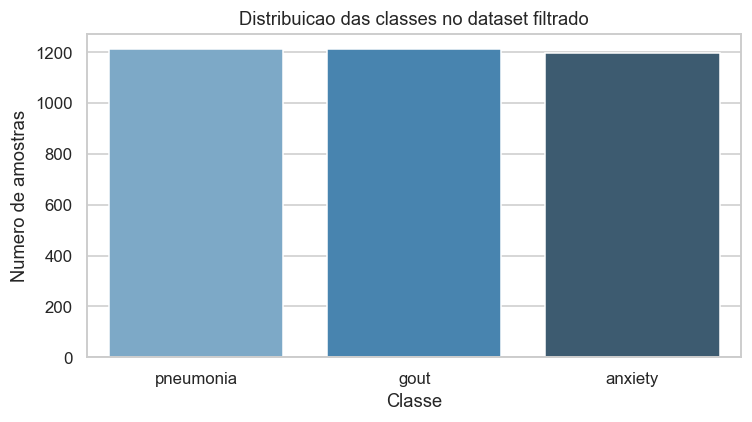

In [2]:
print("Resumo dos datasets")
display(dataset_summary)

print("Resumo dos splits estratificados")
display(split_summary)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=class_distribution, x="classe", y="amostras", hue="classe", palette="Blues_d", dodge=False, legend=False, ax=ax)
ax.set_title("Distribuicao das classes no dataset filtrado")
ax.set_xlabel("Classe")
ax.set_ylabel("Numero de amostras")
plt.tight_layout()
plt.show()

## 4. Resultados

Os resultados de validacao mostram que o baseline foi fraco, com `accuracy = 0.3343` e `F1-macro = 0.1670`. Ja os modelos supervisionados tiveram desempenho muito superior.

Na comparacao entre as estrategias de selecao de atributos, foi possivel reduzir de 34 para 25 variaveis sem perda nas metricas de validacao. Regressao Logistica e Random Forest chegaram a `F1-macro = 1.0000` na validacao. Por isso, a escolha final ficou com a Regressao Logistica por ser mais simples de interpretar.


In [3]:
print("Baseline de validacao")
display(baseline_table.round(4))

print("Comparacao entre estrategias de selecao de atributos e PCA")
display(feature_selection_table.round(4))

print("Comparacao entre modelos candidatos")
display(model_comparison_table.round(4))

print("Atributos selecionados pelo qui-quadrado")
display(selected_features_df)

Baseline de validacao


,experimento,features,accuracy_validacao,f1_macro_validacao
0,DummyClassifier (most_frequent),34,0.3343,0.167
1,Regressao Logistica baseline,34,1.0000,1.000


Comparacao entre estrategias de selecao de atributos e PCA


,abordagem,n_features,accuracy_validacao,f1_macro_validacao
0,Todas as features,34,1.0,1.0
1,VarianceThreshold,34,1.0,1.0
2,SelectKBest chi2,25,1.0,1.0
3,Mutual Information,25,1.0,1.0
4,PCA (20 componentes),20,1.0,1.0


Comparacao entre modelos candidatos


,modelo,melhores_hiperparametros,f1_macro_cv,accuracy_validacao,f1_macro_validacao,escolhido
0,Regressao Logistica,"C=0.01, solver=lbfgs, max_iter=2000",1.0,1.0,1.0,Sim
1,Random Forest,"n_estimators=100, max_depth=None, min_samples_...",1.0,1.0,1.0,Nao


Atributos selecionados pelo qui-quadrado


,ordem,feature
0,1,anxiety and nervousness
1,2,depression
2,3,depressive or psychotic symptoms
3,4,insomnia
4,5,abnormal involuntary movements
5,6,palpitations
6,7,irregular heartbeat
7,8,sore throat
8,9,nasal congestion
9,10,vomiting


In [4]:
print("Metricas finais no conjunto de teste")
display(metrics_summary.round(4))

print("Classification report")
display(classification_report_df)

print("Average precision por classe")
display(average_precision_by_class.round(4))

Metricas finais no conjunto de teste


,metrica,valor
0,Accuracy,0.9986
1,Precision macro,0.9986
2,Recall macro,0.9986
3,F1 macro,0.9986
4,ROC-AUC macro,1.0000
5,Average Precision macro,1.0000
6,Log-loss,0.1637


Classification report


,precision,recall,f1-score,support
pneumonia,0.9959,1.0000,0.9979,243.0000
gout,1.0000,1.0000,1.0000,242.0000
anxiety,1.0000,0.9958,0.9979,240.0000
accuracy,0.9986,0.9986,0.9986,0.9986
macro avg,0.9986,0.9986,0.9986,725.0000
weighted avg,0.9986,0.9986,0.9986,725.0000


Average precision por classe


,classe,average_precision
0,anxiety,0.9999
1,gout,1.0000
2,pneumonia,0.9999


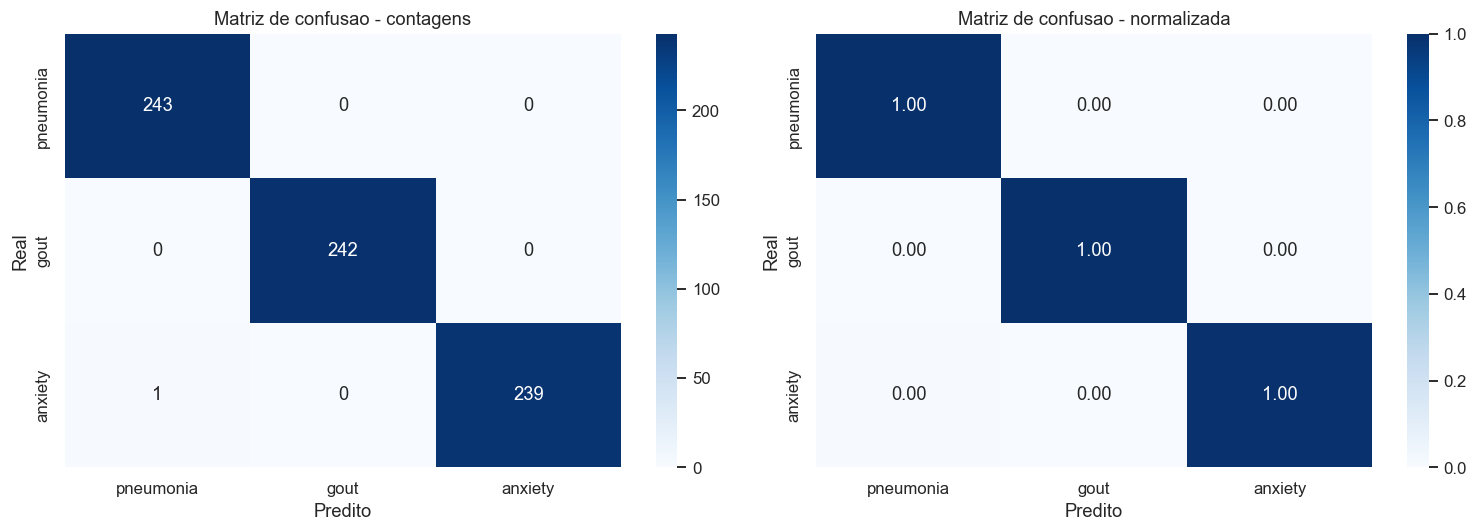

Matriz de confusao em tabela


,pneumonia,gout,anxiety
pneumonia,243,0,0
gout,0,242,0
anxiety,1,0,239


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(y_test, y_pred, labels=display_order, ax=axes[0], normalize=None)
plot_confusion_matrix(y_test, y_pred, labels=display_order, ax=axes[1], normalize="true")
axes[0].set_title("Matriz de confusao - contagens")
axes[1].set_title("Matriz de confusao - normalizada")
plt.tight_layout()
plt.show()

print("Matriz de confusao em tabela")
display(metrics_test["confusion_matrix"])

No conjunto de teste, o modelo final obteve `accuracy = 0.9986`, `precision macro = 0.9986`, `recall macro = 0.9986`, `F1-macro = 0.9986` e `ROC-AUC macro = 1.0000`. A matriz de confusao mostra que o modelo classificou corretamente todos os exemplos de `pneumonia` e `gout`.

O unico erro ocorreu em um registro de `anxiety`, que foi previsto como `pneumonia`. Isso indica que, dentro do recorte escolhido, as tres classes ficaram muito bem separadas pelos sintomas presentes no dataset.


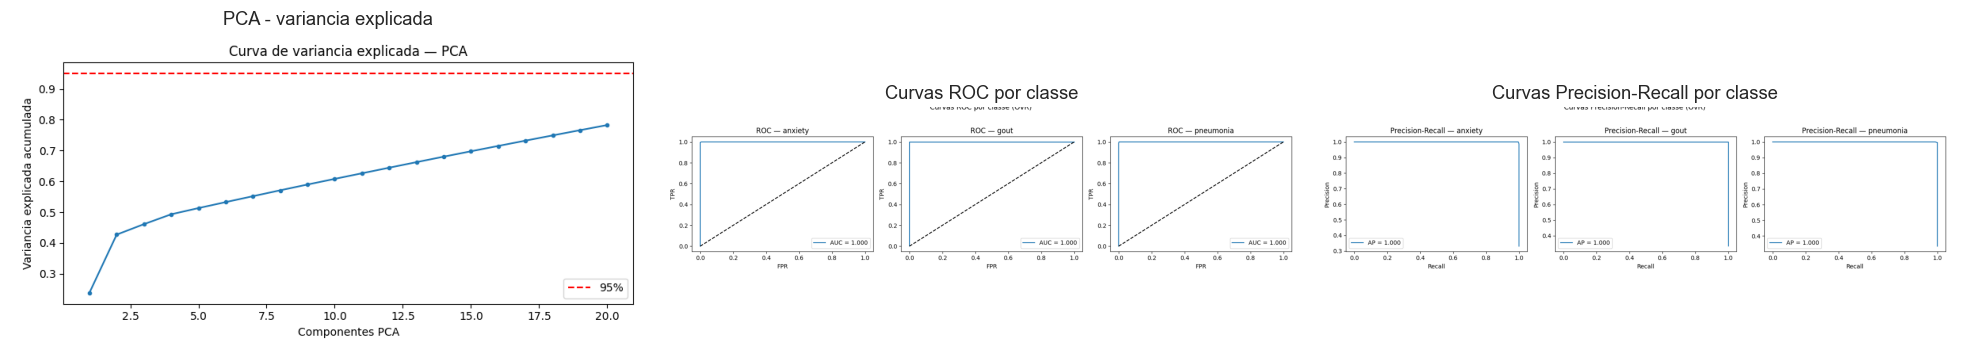

In [6]:
figure_specs = [
    ("PCA - variancia explicada", project_root / "data" / "figs" / "pca_variance.png"),
    ("Curvas ROC por classe", project_root / "data" / "figs" / "roc_curves.png"),
    ("Curvas Precision-Recall por classe", project_root / "data" / "figs" / "pr_curves.png"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, path) in zip(axes, figure_specs):
    if path.exists():
        ax.imshow(mpimg.imread(path))
        ax.set_title(title)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Figura ausente:\n{path.name}", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Discussao

O principal ponto do projeto e que o recorte das tres doencas gerou um problema bem comportado para classificacao. Alem disso, a etapa de selecao de atributos mostrou que o modelo pode ficar mais enxuto sem perder desempenho.

Mesmo com resultados muito altos, a interpretacao deve ficar limitada ao dataset usado no projeto. Ou seja, o que podemos afirmar aqui e que o pipeline funcionou muito bem para esse conjunto de dados e para essas tres classes especificas.


In [7]:
error_summary = pd.DataFrame(
    [
        {
            "total_amostras_teste": len(X_test),
            "total_erros": len(errors),
            "taxa_erro": len(errors) / len(X_test),
        }
    ]
)

print("Resumo da analise de erros")
display(error_summary.round(4))

if not error_pairs.empty:
    print("Distribuicao dos erros por par real -> predito")
    display(error_pairs)

if not error_feature_summary.empty:
    print("Top-5 sintomas entre os casos classificados incorretamente")
    display(error_feature_summary.round(4))
else:
    print("Nao houve erros no conjunto de teste.")

Resumo da analise de erros


,total_amostras_teste,total_erros,taxa_erro
0,725,1,0.0014


Distribuicao dos erros por par real -> predito


,diseases,predito,quantidade
0,anxiety,pneumonia,1


Top-5 sintomas entre os casos classificados incorretamente


,presenca_media
anxiety and nervousness,0.0
depression,0.0
depressive or psychotic symptoms,0.0
insomnia,0.0
abnormal involuntary movements,0.0


## 6. Conclusao

Este trabalho mostrou que e possivel classificar `pneumonia`, `gout` e `anxiety` com otimo desempenho usando os sintomas do dataset filtrado. O melhor modelo foi a Regressao Logistica com 25 atributos selecionados por qui-quadrado.

Alem de atender ao requisito de selecao de variaveis, o modelo final manteve alta qualidade no teste e errou apenas 1 entre 725 amostras. Assim, o projeto cumpre o objetivo da disciplina: construir, avaliar e discutir um classificador a partir de um dataset de sintomas.
